# Module 2: Epidemic Modeling

## Team Members: 
### Sara Elster, Dani Folks

## Project Title: 
### *Modeling the Impact of a Novel Virus on Population Dynamics and Intervention Strategies*

## Project Goal:
### This project seeks to characterize and predict the spread of an unknown virus utilizing exponential growth modeling and SEIR simulation, and to evaluate the effectiveness of various intervention strategies implemented during the outbreak.

## 1. Data and disease background
The outbreak of this unknown virus within the UVA and VT populations demonstrated significant transmission dynamics, with a prevalence of 18.3% of the total UVA population infected and an incidence of 0.83% of the UVA population at the virus' peak transmission (Day 83). The virus is a (+) ssRNA virus measuring 50-80 nm with a ~10 kb genome. It is transmitted through respiratory droplets and exhibits an incubation period of 12-18 days and a symptomatic period of 5-9 days. However, it was determined that individuals are infectious up to 2 days before the start of the symptomatic period. Symptoms of the disease include mild respiratory symptoms, such as sore throat, low-grade fever, and fatigue, as well as rash, gastrointestinal symptoms, and joint pain. Biological mechanisms of the virus likely involve inhalation of viral respiratory droplets when an infected person coughs, entry into host respiratory epithelial cells via endocytosis, hijacking of host cells for production of viral proteins, replication of viral genome, and release to infect more cells. This leads to inflammation in the respiratory tract as well as immune responses. Economically, respiratory viruses can impede community function, especially of a university. Viral epidemics often lead to increased healthcare utilization, lower attendance in class, reduced productivity, and places strain on university health services.

## 2. Data Analysis
This section should be filled out sequentially as a full report of the work you've done over this module. You can copy and paste code from any main.py file here, and run it to produce plots. Once you gain more information throughout the module, you do not need to go back and "fix" earlier results. In other words, if your early predictions are found to be wrong when gaining new data, do not go back and rewrite them.

### 2a. Methods

*IN A SUMMARY, DESCRIBE THE METHODS YOU USED TO ANALYZE AND MODEL THE DATA.*


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #1</b> 

</div>



### 2b. Plot the data & estimate initial growth rate (R0) from early data (through day 45)
This section should come from your python code after Data Release #1.

First, we imported the libraries necessary for computation and loaded the data from release 1.

In [27]:
# Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# Load the data
data = pd.read_csv(r'/Users/saraelster/Desktop/UVA/Computational BME/Module 2/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#1.csv', parse_dates=['date'], header=0, index_col=None)

Next, we used the Scipy curve_fit function to estimate R0 from the data.

In [28]:
# We used the day number and active cases to fit an exponential growth curve to estimate R0
# Defining the exponential growth function
def exponential_growth(t, r):
    return np.exp(r * t)

# Fitting the exponential growth model to the data with scipy curve_fit
x_data = data['day'].values.astype(float)
y_data = data['active reported daily cases'].values.astype(float)
popt, pcov = curve_fit(exponential_growth, x_data, y_data)

r_fit = popt[0]

# Approximate R0
D = 9 # Background said the symptomatic period is 5-9 days, but with 2 days infectious before symptoms appear. We took the average for the infectious period to be 9 days.

r0 = np.exp(r_fit * D)

print("Estimated growth rate R0: ", r0)

Estimated growth rate R0:  2.9832723355682464


Finally, we added the fitted exponential curve to the actual virus data to see whether it was a good estimate.

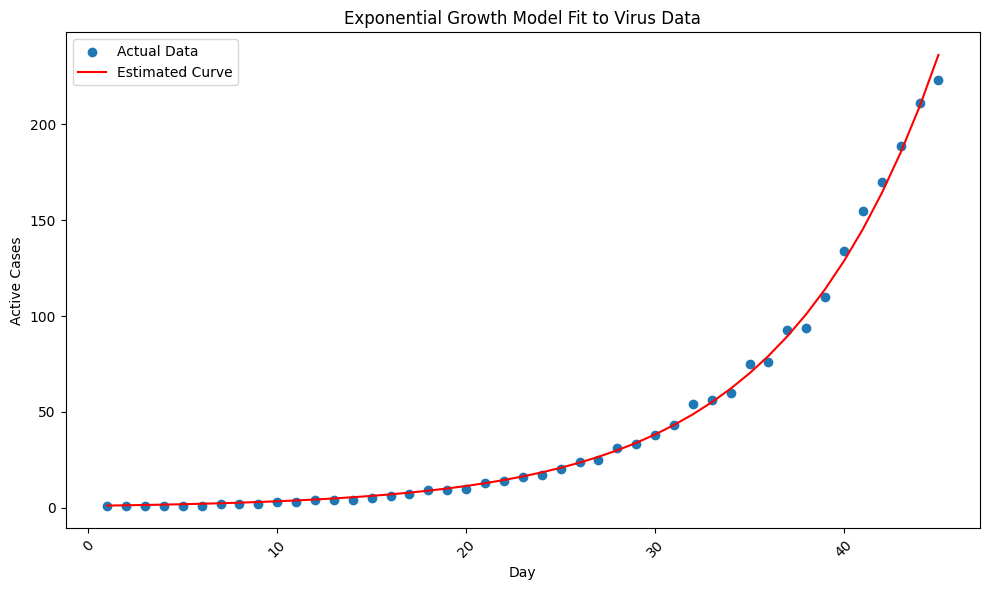

In [29]:
# Add the fit as a line on top of your scatterplot.
# Generate fitted curve
y_fitted = exponential_growth(x_data, r_fit)

# Plot fitted curve and actual data
plt.figure(figsize=(10, 6))
plt.scatter(x_data, y_data, label = "Actual Data")
plt.plot(x_data, y_fitted, color = "red", label = "Estimated Curve")
plt.xlabel('Day')
plt.ylabel('Active Cases')
plt.title('Exponential Growth Model Fit to Virus Data')
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show() 

##### Preliminary Analysis/Conclusions:

**Analysis of Data Release 1:**
1. What do you notice about initial infections?

The initial infections seem to be very low, with only a few cases reported in the early days. This could indicate that the virus was not spreading widely at the beginning, or that there was limited testing and reporting.

2. How could we measure how quickly its spreading?

We could measure how quickly the virus is spreading by calculating the growth rate of active cases over time. This can be done by taking the difference in active cases between consecutive days and dividing it by the number of active cases on the previous day to get a percentage growth rate. 

3. What information about the virus would be helpful in determining the shape of the outbreak curve?

Information about the virus's transmission rate, incubation period, and recovery time would be helpful in determining the shape of the outbreak curve.


**Conclusions:**

Our estimated R0 was 2.98. Two viruses with a similar R0 value of 3 are COVID-19 and Meningococcal Disease. COVID-19 is a respiratory virus caused by the coronavirus *SARS-CoV-2*. It spreads through respiratory droplets and aerosols and symptoms range from fever and cough to severe illness infecting the lungs and other organs. The Meningococcal Disease is a bacterial infection caused by *Neisseria meningitidis*. It is spread through close respiratory or throat contact, and can lead to meningitis and bloodstream infections.

Generally, we believe our R0 estimate is accurate. However, because the symptomatic period given was a range of 5-9 days, our value for infectious period (D) may not be completely accurate, which would affect the calculation of R0.

### 2c. Use Euler's method to solve the SEIR model.

First, we imported the necessary libraries.

In [30]:
#%% SEIR model fitting with Euler's method
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Next, we pulled the dataset from Data Release 2 and organized the days and cases into their own data sets.

In [31]:
# Loading the data
data_2 = pd.read_csv(r"/Users/saraelster/Desktop/UVA/Computational BME/Module 2/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#2.csv", parse_dates=['date'], header=0, index_col=None)

timepoints = data_2['day'].values.astype(float)
infected_data = data_2['active reported daily cases'].values.astype(float)

Finally, we used Euler's method to approximate S, E, I, and R parameters of SEIR model.

In [32]:
# Initial conditions
N = 17900           # total UVA population
I0 = infected_data[0]
E0 = I0             # reasonable first guess: exposed starts similar to infected
R0_init = 0         # initial recovered is 0
S0 = N - E0 - I0 - R0_init

# Euler method for SEIR
def euler_seir(timepoints, N, S0, E0, I0, R0, beta, sigma, gamma):
    dt = timepoints[1] - timepoints[0]

    S = np.zeros(len(timepoints))
    E = np.zeros(len(timepoints))
    I = np.zeros(len(timepoints))
    R = np.zeros(len(timepoints))

    S[0] = S0
    E[0] = E0
    I[0] = I0
    R[0] = R0

    for i in range(len(timepoints) - 1):
        dSdt = -beta * S[i] * I[i] / N
        dEdt = beta * S[i] * I[i] / N - sigma * E[i]
        dIdt = sigma * E[i] - gamma * I[i]
        dRdt = gamma * I[i]

        S[i + 1] = S[i] + dSdt * dt
        E[i + 1] = E[i] + dEdt * dt
        I[i + 1] = I[i] + dIdt * dt
        R[i + 1] = R[i] + dRdt * dt

    return S, E, I, R

### 2d. Fit the SEIR model to the data by changing beta, gamma, and sigma.

First, we used SSE to determine the optimal values for beta, sigma, and gamma, and the corresponding SSE.

In [33]:
# SSE calculation
def calculate_sse(model_I, data_I):
    return np.sum((model_I - data_I) ** 2)

# Parameter search
def fit_seir_parameters(timepoints, N, S0, E0, I0, R0, infected_data):
    # These are reasonable starter ranges for a daily-timescale outbreak
    beta_values = np.linspace(0.1, 1.2, 30)
    sigma_values = np.linspace(0.05, 0.6, 25)
    gamma_values = np.linspace(0.05, 0.6, 25)

    best_sse = np.inf
    best_beta = None
    best_sigma = None
    best_gamma = None

    sse_results = []

    for b in beta_values:
        for s in sigma_values:
            for g in gamma_values:
                S, E, I, R = euler_seir(timepoints, N, S0, E0, I0, R0, b, s, g)
                sse = calculate_sse(I, infected_data)
                sse_results.append((b, s, g, sse))

                if sse < best_sse:
                    best_sse = sse
                    best_beta = b
                    best_sigma = s
                    best_gamma = g

    return best_beta, best_sigma, best_gamma, best_sse, sse_results

### 2e. Plot the model-predicted infections over time compared to the data.
This section should come from your python code after Data Release #2.

Finally, we ran the calculations and plotted the corresponding best fit model with the actual data.

Best beta = 0.3275862068965517
Best sigma = 0.5770833333333334
Best gamma = 0.14166666666666666
Best SSE = 74115.92618245789


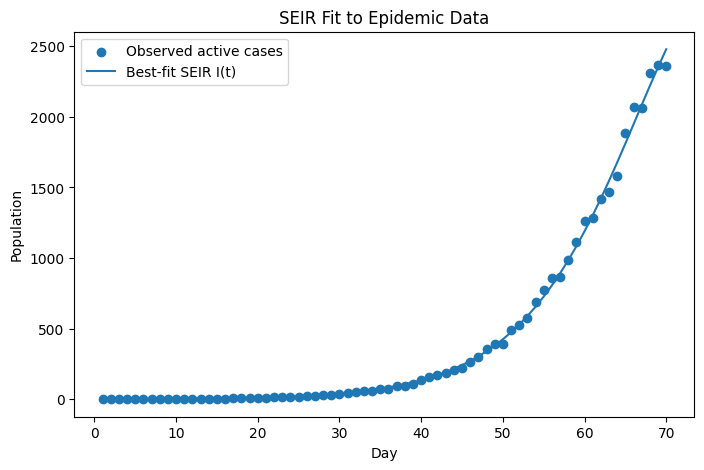

In [34]:
# Fit the model
best_beta, best_sigma, best_gamma, best_sse, sse_results = fit_seir_parameters(
    timepoints, N, S0, E0, I0, R0_init, infected_data
)

print("Best beta =", best_beta)
print("Best sigma =", best_sigma)
print("Best gamma =", best_gamma)
print("Best SSE =", best_sse)

# Run best-fit model on observed time window
S_fit, E_fit, I_fit, R_fit = euler_seir(
    timepoints, N, S0, E0, I0, R0_init,
    best_beta, best_sigma, best_gamma
)

# Plot model fit vs data
plt.figure(figsize=(8, 5))
plt.scatter(timepoints, infected_data, label='Observed active cases')
plt.plot(timepoints, I_fit, label='Best-fit SEIR I(t)')
plt.xlabel('Day')
plt.ylabel('Population')
plt.title('SEIR Fit to Epidemic Data')
plt.legend()
plt.show()

### 2e. Predict the day and amount of active cases at the peak of the epidemic spread.
This section should come from your python code after Data Release #2.

To predict the peak and plot the predicted graph, we calculated future timepoints until day 200 using the approximated S, E, I, and R values. Then, we used these values to predict what the peak number of cases would be and the corresponding day.

In [35]:
# Predict the future peak
future_days = 120
future_timepoints = np.arange(timepoints[0], timepoints[0] + future_days + 1, 1)

S_future, E_future, I_future, R_future = euler_seir(
    future_timepoints, N, S0, E0, I0, R0_init,
    best_beta, best_sigma, best_gamma
)

peak_index = np.argmax(I_future)
peak_day = future_timepoints[peak_index]
peak_value = I_future[peak_index]

print("Predicted peak infected population =", peak_value)
print("Predicted peak day =", peak_day)


Predicted peak infected population = 3035.236821284492
Predicted peak day = 78.0


Finally, we used the predicted data to plot the predicted graph of number of cases vs days as well as the peak number of cases and days.

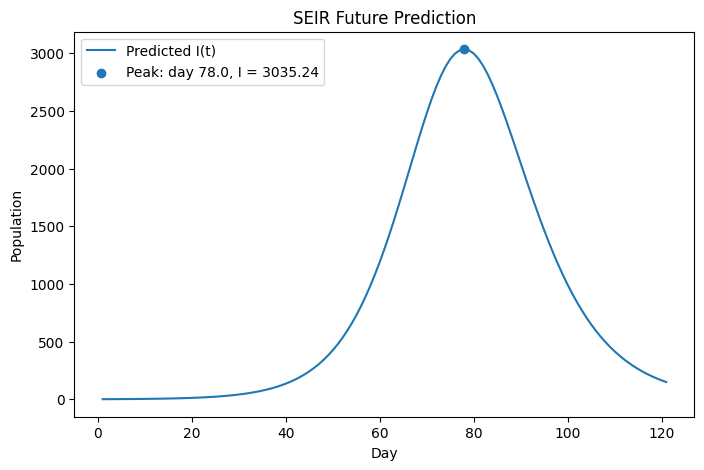

In [36]:
# Plot future prediction
plt.figure(figsize=(8, 5))
plt.plot(future_timepoints, I_future, label='Predicted I(t)')
plt.scatter(peak_day, peak_value, label=f'Peak: day {peak_day}, I = {peak_value:.2f}')
plt.xlabel('Day')
plt.ylabel('Population')
plt.title('SEIR Future Prediction')
plt.legend()
plt.show()

### 2f. Plot the full dataset (Data Release #3) against your model.

First, we loaded the actual data from data release 3.


In [37]:
# Loading data from data release 3
data_3 = pd.read_csv(r'/Users/saraelster/Desktop/UVA/Computational BME/Module 2/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#3.csv', parse_dates=['date'], header=0, index_col=None)

x_data_actual = data_3['day'].values.astype(float)
y_data_actual = data_3['active reported daily cases'].values.astype(float)

Once the data was loaded, we were able to plot the actual data with the predicted curve.

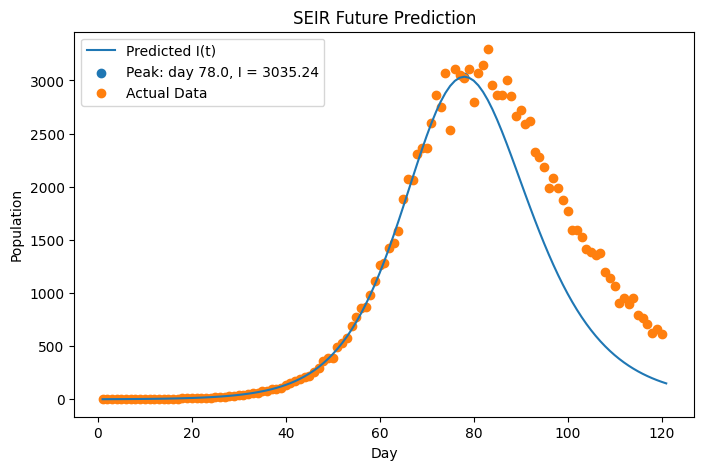

In [38]:
# Plotting full dataset against SEIR model
plt.figure(figsize=(8, 5))
plt.plot(future_timepoints, I_future, label='Predicted I(t)')
plt.scatter(peak_day, peak_value, label=f'Peak: day {peak_day}, I = {peak_value:.2f}')
plt.scatter(x_data_actual, y_data_actual, label = "Actual Data")
plt.xlabel('Day')
plt.ylabel('Population')
plt.title('SEIR Future Prediction')
plt.legend()
plt.show()

Finally, we calculated both the true and relative error for both the predicted peak number of cases and peak day of infection. To do this, we iterated through data set 3 to find the actual peak number of cases and corresponding day, then calculated the true and relative errors based off of these numbers.

In [39]:
# Estimating error

# Finding actual peak value and day from data release 3
actual_peak_value = 0
actual_peak_day = 0
for num in range(len(y_data_actual)):
    if y_data_actual[num] > actual_peak_value:
        actual_peak_value = y_data_actual[num]
        actual_peak_day = x_data_actual[num]
print("Actual peak number of cases", actual_peak_value)
print("Actual peak day:", actual_peak_day)

# Calculating true error for value and day
true_error_value = actual_peak_value - peak_value
true_error_day = actual_peak_day - peak_day
print("True error for peak number of cases:", round(true_error_value, 2))
print("True error value for peak day:", true_error_day)

# Calculating percent error
rel_error_value = (true_error_value/actual_peak_value)*100
rel_error_day = (true_error_day/actual_peak_day)*100
print("Relative (%) error for peak number if cases: " + str(round(rel_error_value, 2)) + "%")
print("Relative (%) error for peak day: " + str(round(rel_error_day, 2)) + "%")

Actual peak number of cases 3294.0
Actual peak day: 83.0
True error for peak number of cases: 258.76
True error value for peak day: 5.0
Relative (%) error for peak number if cases: 7.86%
Relative (%) error for peak day: 6.02%


### 2g. Intervention strategies for new outbreak at VT (70 days of infection)

The intervention strategies we modeled were masking mandates, testing/quarantine starting at day 70, and closing school for two weeks.



## Verify and validate your analysis: 

*(Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., a published paper).*

## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*